# Insurance Cost Prediction

## Overview
This project analyzes insurance data to predict medical insurance charges.

## Tasks Performed
- Loaded the insurance dataset
- Explored numerical and categorical features
- Encoded categorical variables
- Performed data preprocessing
- Built regression models
- Evaluated prediction accuracy

## Libraries Used
- Pandas
- Scikit-learn

## Goal
Predict medical insurance charges using customer information.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [8]:
df.nunique()

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [9]:
df["sex"].unique()

array(['female', 'male'], dtype=object)

In [10]:
df["sex"] = df["sex"].map({
    "male":1,
    "female":0
})

In [11]:
df["smoker"].unique()

array(['yes', 'no'], dtype=object)

In [12]:
df["smoker"] = df["smoker"].map({
    "yes":1,
    "no":0
})

In [13]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [14]:
df["region"].unique()

array(['southwest', 'southeast', 'northwest', 'northeast'], dtype=object)

In [15]:
df["region"] = df["region"].map({
    'southwest':0,
    'southeast':1, 
    'northwest':2,
    'northeast':3
})

In [16]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB


In [18]:
import matplotlib.pyplot as plt

In [19]:
import seaborn as sns

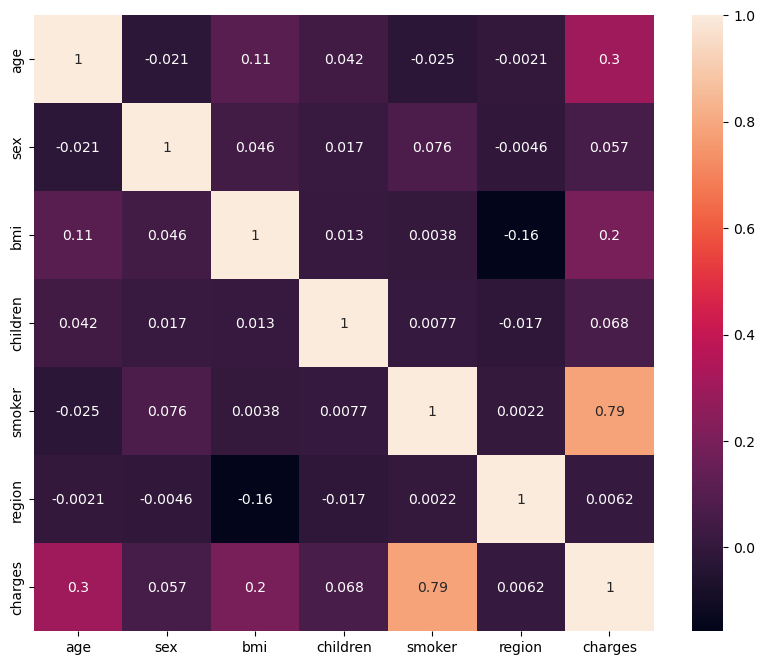

In [20]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True)
plt.show()

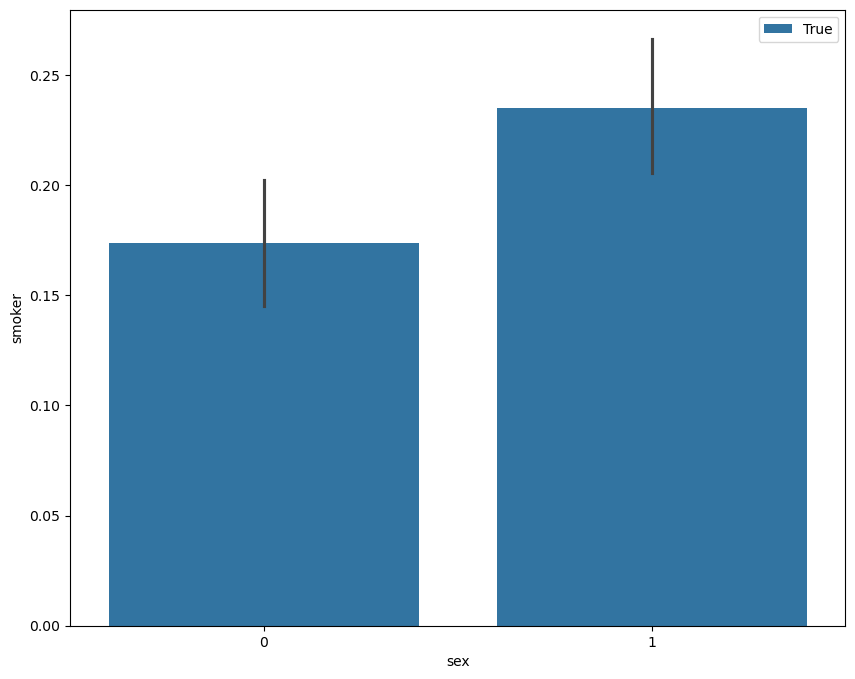

In [21]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x="sex",y="smoker",hue=True)
plt.show()

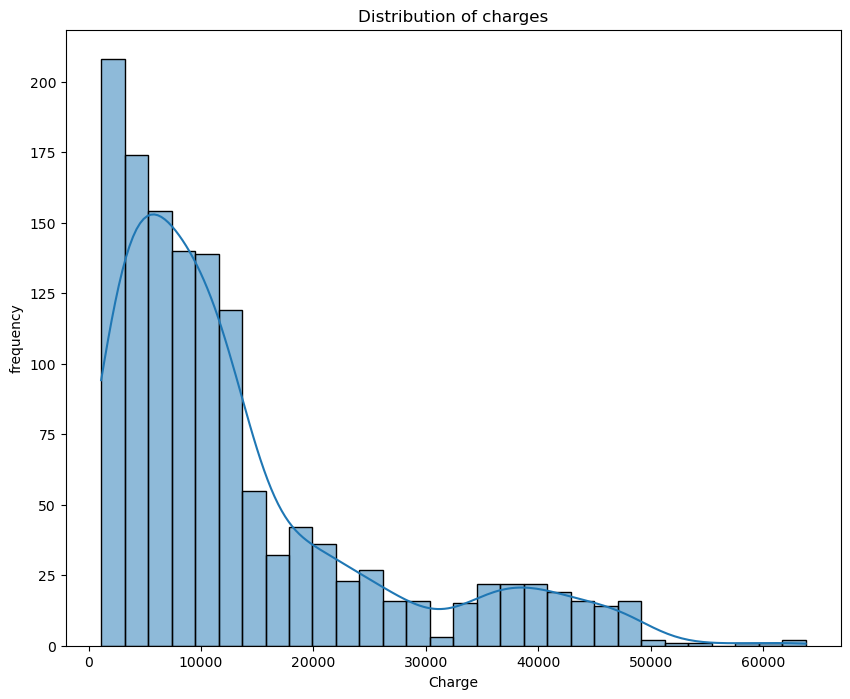

In [22]:
plt.figure(figsize=(10,8))
sns.histplot(df['charges'],bins=30,kde=True)
plt.title("Distribution of charges")
plt.xlabel("Charge")
plt.ylabel("frequency")
plt.show()

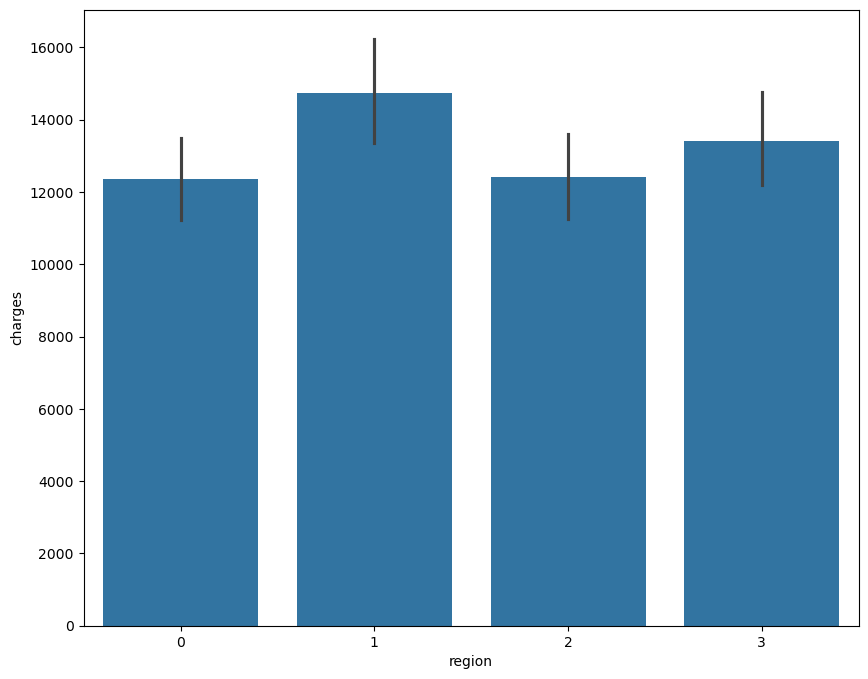

In [24]:
plt.figure(figsize=(10,8))
sns.barplot(x='region',y='charges',data=df)
plt.show()

In [26]:
Y = df['charges']

In [27]:
X = df.drop("charges",axis=1)

In [28]:
from sklearn.model_selection import train_test_split

In [35]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
model = LinearRegression()

In [44]:
model.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
y_perd = model.predict(X_test)

In [47]:
y_perd

array([ 8924.40724442,  7116.29501758, 36909.01352144,  9507.87469118,
       27013.3500079 , 10790.77956153,   226.29844571, 16942.71599941,
        1056.63079407, 11267.91997309, 28048.59793155,  9424.36324087,
        5326.32232088, 38460.06017922, 40303.40597026, 37147.01010262,
       15287.91876684, 35965.05485917,  9179.1753067 , 31510.8319849 ,
        3797.79068365, 10070.82803304,  2312.57551348,  7074.41348194,
       11352.37224357, 12907.77079523, 14448.84678727,  6205.65997921,
        9917.00839638,  2239.50032819,  9060.55469043, 13120.56214535,
        4617.70702822,  3467.91218926,  4402.74821855, 12967.91608907,
        1927.44498944,  8757.9180081 , 33324.35180597, 32638.47697026,
        3852.41756615,  4370.39670883, 14080.76023234, 11478.63402576,
        8829.26135924, 12046.15119133,  5322.80515731,  3100.71182484,
       35546.60547574,  9201.61196817, 15894.23763341,  2406.04003607,
       12397.52052544,  1433.90617387, 13448.14094304, 12519.54174599,
      

In [48]:
from sklearn.metrics import r2_score

In [54]:
score = r2_score(Y_test,y_perd)

In [55]:
from sklearn.metrics import mean_absolute_error

Mean Absolute Error: 4186.51


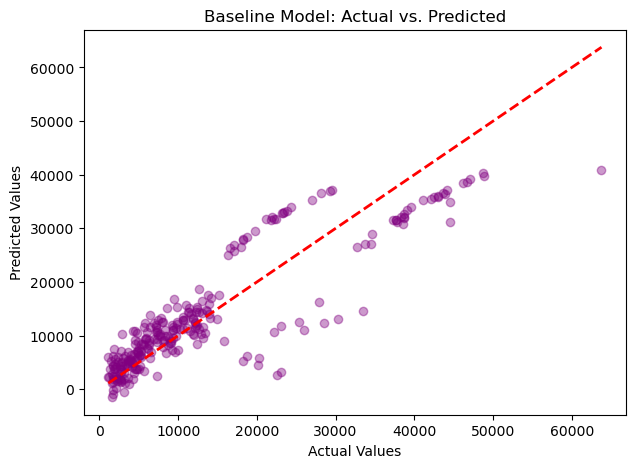

In [56]:
mae = mean_absolute_error(Y_test, y_perd)
print(f"Mean Absolute Error: {mae:.2f}")

plt.figure(figsize=(7, 5))
plt.scatter(Y_test, y_perd, alpha=0.4, color='purple')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Baseline Model: Actual vs. Predicted')
plt.show()

In [57]:
print(f"Model R^2 Score: {score:.3f}")

if score > 0.60:
    print("Verdict: FEASIBLE. The model shows strong predictive power. Proceed with this ML approach.")
else:
    print("Verdict: REJECT/RE-EVALUATE. The model performance is too low; consider tuning or different features.")

Model R^2 Score: 0.783
Verdict: FEASIBLE. The model shows strong predictive power. Proceed with this ML approach.


In [58]:
from sklearn.ensemble import RandomForestRegressor

In [60]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)



,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
y_pred_rf = rf.predict(X_test)

In [62]:
y_pred_rf

array([11540.720813  ,  5288.3588865 , 28343.209995  , 10678.2981118 ,
       34550.9469959 ,  8816.4044072 ,  2081.2568995 , 14551.4158513 ,
        5922.4791368 , 10621.3698822 , 20089.5637777 ,  7181.840342  ,
        4925.883118  , 46507.9670218 , 48399.8769195 , 45507.8492035 ,
        9914.1335171 , 43391.1019815 ,  9304.5980411 , 24391.0463718 ,
        6074.7686235 , 10257.2096643 ,  1993.0793624 ,  2766.8325518 ,
       12116.1768352 , 12138.3628771 , 13227.7790395 ,  6707.8948725 ,
       10829.7568749 ,  5211.41406642,  7684.819416  , 11733.685097  ,
        2481.8461755 ,  5485.3114346 ,  3162.2096487 , 10688.618701  ,
        2694.7465165 ,  8110.0185398 , 23571.8334495 , 39342.5137565 ,
        6435.5497528 ,  2768.7070763 , 12299.4463425 , 14500.2453471 ,
        6007.5917156 , 15134.8024641 , 14529.2087613 ,  5424.0562419 ,
       42248.676601  ,  7624.6331623 , 13848.9700505 ,  2264.54657735,
        6869.5747731 ,  1825.41929275, 12183.4849849 , 11684.7413449 ,
      

In [63]:
score = r2_score(Y_test,y_pred_rf)

In [64]:
score

0.8636743861643307

In [65]:
print(f"Model R^2 Score: {score:.3f}")

if score > 0.60:
    print("Verdict: FEASIBLE. The model shows strong predictive power. Proceed with this ML approach.")
else:
    print("Verdict: REJECT/RE-EVALUATE. The model performance is too low; consider tuning or different features.")

Model R^2 Score: 0.864
Verdict: FEASIBLE. The model shows strong predictive power. Proceed with this ML approach.


In [66]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2 Score": [
        r2_score(y_test, y_perd),
        r2_score(y_test, y_pred_rf)
    ]
})

results

,Model,R2 Score
0,Linear Regression,0.783346
1,Random Forest,0.863674


In [67]:
import joblib as jb 

In [68]:
jb.dump(model,"insurance_model.pkl")

['insurance_model.pkl']

In [69]:
jb.load("insurance_model.pkl")

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False
